In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

MERGED = Path("../data/results/runs/multi_pdf/2026-04-17_multi_pdf_eval/merged/multi_pdf_eval.csv")
COMBINED_QA = Path("../data/results/runs/multi_pdf/2026-04-17_multi_pdf_eval/meta/combined_multi_pdf_qa.csv")

In [2]:
df = pd.read_csv(MERGED)
df.columns = df.columns.str.strip()

# Parse latency from "1.97 Seconds" string
df["latency_sec"] = df["total_elapsed_time"].str.extract(r"([\d\.]+)")[0].astype(float)

# Compute price per query
rates = {"nano": 0.40, "mini": 2.00}
def _rate(model):
    for k, v in rates.items():
        if k in str(model).lower():
            return v
    return 1.00
df["price_usd"] = df.apply(lambda r: (r["meta_total_tokens"] / 1_000_000) * _rate(r["model"]), axis=1)

# Cast judge booleans
for col in ["judge_answer_correctness_vs_ref", "judge_answer_helpfulness"]:
    df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])

# Map question -> machine
qa_map = pd.read_csv(COMBINED_QA).set_index("question")["machine"]
df["machine"] = df["question"].map(qa_map)

print(f"Rows: {len(df)}")
print(f"Approaches: {sorted(df['approach'].unique())}")
print(f"Models:     {sorted(df['model'].unique())}")
print(f"Machines:   {sorted(df['machine'].dropna().unique())}")
df.head(2)

Rows: 972
Approaches: ['long_context', 'openai_keyword', 'openai_semantic']
Models:     ['gpt-5.4-mini-2026-03-17', 'gpt-5.4-nano-2026-03-17']
Machines:   ['Lathe (HAAS TL-1)', 'Mill (Bridgeport)', 'UR5e Cobot']


,permutation_id,time_started,time_ended,total_elapsed_time,min_words_for_subsplit,approach,model,max_tokens,reasoning_effort,top_k,...,rougeL,bleu,q,judge_answer_correctness_vs_ref,judge_answer_helpfulness,text_correctness_vs_ref,text_helpfulness,latency_sec,price_usd,machine
0,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:38 EDT,8.76 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.095238,0.003962,DANGER\r\nDANGER indicates a hazardous situati...,False,False,Correctness: False\n\nStep-by-step reasoning:\...,Relevance: False\n\nStep-by-step reasoning:\n-...,8.76,0.016870,Mill (Bridgeport)
1,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:35 EDT,5.70 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.171779,0.006596,DANGER(Red with white text)\r\nDANGER indicate...,False,False,Correctness: False\n\nStep-by-step reasoning:\...,Relevance: False\n\nStep-by-step reasoning:\n-...,5.70,0.014984,Mill (Bridgeport)


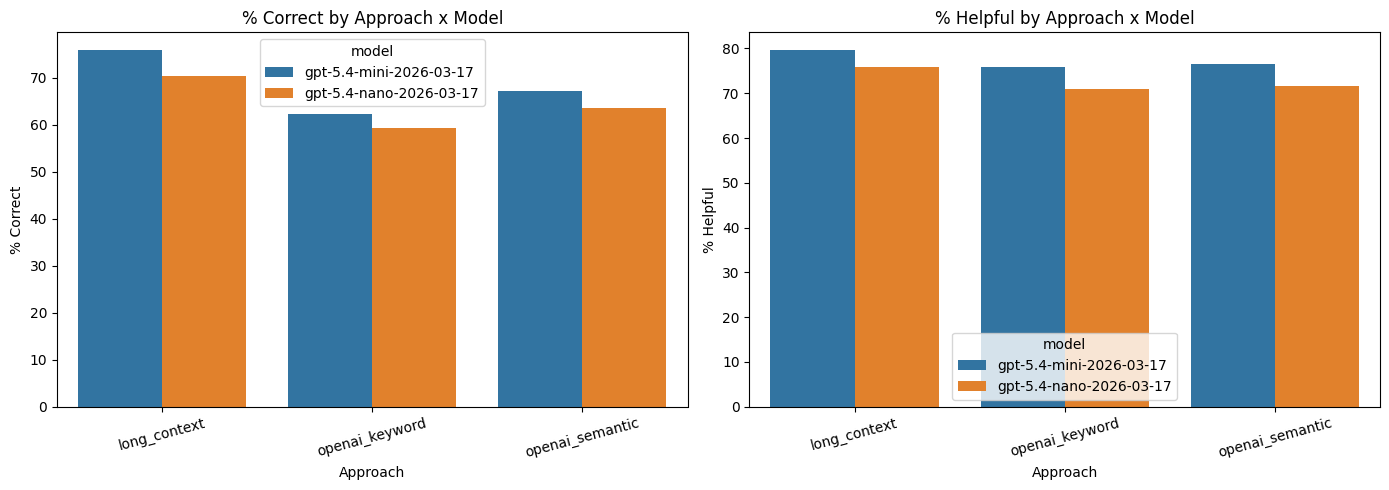

,approach,model,pct_correct,pct_helpful
0,long_context,gpt-5.4-mini-2026-03-17,75.925926,79.629630
1,long_context,gpt-5.4-nano-2026-03-17,70.370370,75.925926
4,openai_semantic,gpt-5.4-mini-2026-03-17,67.283951,76.543210
5,openai_semantic,gpt-5.4-nano-2026-03-17,63.580247,71.604938
2,openai_keyword,gpt-5.4-mini-2026-03-17,62.345679,75.925926
3,openai_keyword,gpt-5.4-nano-2026-03-17,59.259259,70.987654


In [3]:
# Chart 1: Correctness & Helpfulness by Approach x Model
agg = (
    df.groupby(["approach", "model"])
    .agg(
        pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100),
        pct_helpful=("judge_answer_helpfulness", lambda x: x.mean() * 100),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=agg, x="approach", y="pct_correct", hue="model", ax=axes[0])
axes[0].set_title("% Correct by Approach x Model")
axes[0].set_xlabel("Approach"); axes[0].set_ylabel("% Correct")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=agg, x="approach", y="pct_helpful", hue="model", ax=axes[1])
axes[1].set_title("% Helpful by Approach x Model")
axes[1].set_xlabel("Approach"); axes[1].set_ylabel("% Helpful")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()
display(agg.sort_values("pct_correct", ascending=False))

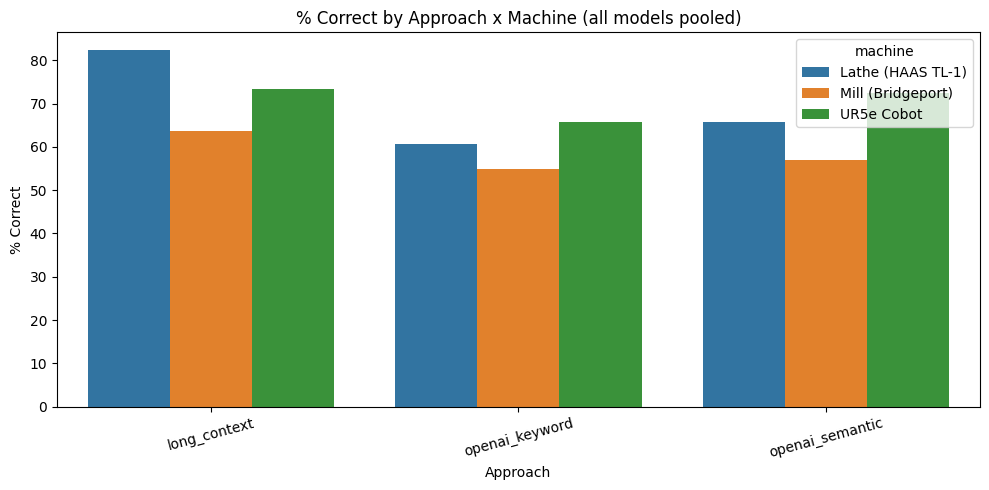

,approach,machine,pct_correct
0,long_context,Lathe (HAAS TL-1),82.352941
2,long_context,UR5e Cobot,73.333333
8,openai_semantic,UR5e Cobot,72.500000
5,openai_keyword,UR5e Cobot,65.833333
6,openai_semantic,Lathe (HAAS TL-1),65.686275
1,long_context,Mill (Bridgeport),63.725490
3,openai_keyword,Lathe (HAAS TL-1),60.784314
7,openai_semantic,Mill (Bridgeport),56.862745
4,openai_keyword,Mill (Bridgeport),54.901961


In [4]:
# Chart 2: Per-Machine Correctness — Approach x Machine
agg_machine = (
    df.groupby(["approach", "machine"])
    .agg(pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=agg_machine, x="approach", y="pct_correct", hue="machine", ax=ax)
ax.set_title("% Correct by Approach x Machine (all models pooled)")
ax.set_xlabel("Approach"); ax.set_ylabel("% Correct")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()
display(agg_machine.sort_values("pct_correct", ascending=False))

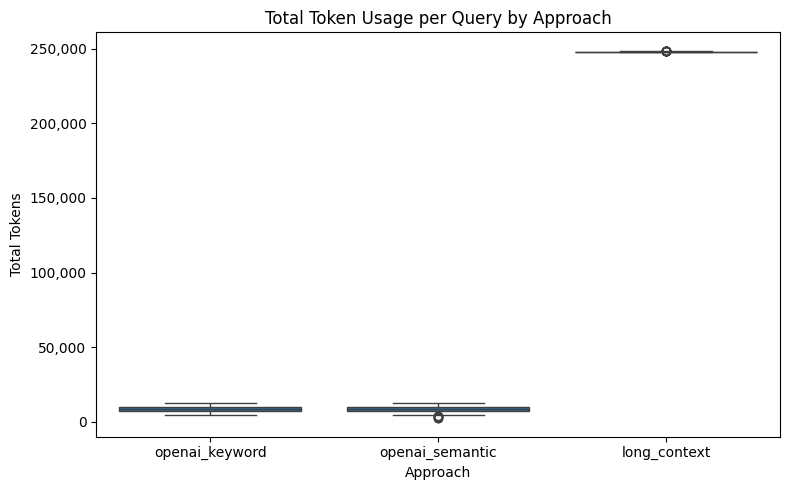

                count     mean    std      min      25%      50%      75%  \
approach                                                                    
long_context      324  247,917    111  247,772  247,842  247,891  247,955   
openai_keyword    324    8,743  1,759    4,579    7,525    8,766    9,904   
openai_semantic   324    8,563  1,783    2,498    7,567    8,694    9,778   

                     max  
approach                  
long_context     248,635  
openai_keyword    12,661  
openai_semantic   12,567  


C:\Users\singhr7\AppData\Local\Temp\ipykernel_29768\189375081.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df.groupby("approach")["meta_total_tokens"].describe().applymap(lambda x: f"{x:,.0f}"))


In [5]:
# Chart 3: Token Usage Distribution by Approach
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="approach", y="meta_total_tokens", ax=ax)
ax.set_title("Total Token Usage per Query by Approach")
ax.set_xlabel("Approach"); ax.set_ylabel("Total Tokens")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()
print(df.groupby("approach")["meta_total_tokens"].describe().applymap(lambda x: f"{x:,.0f}"))

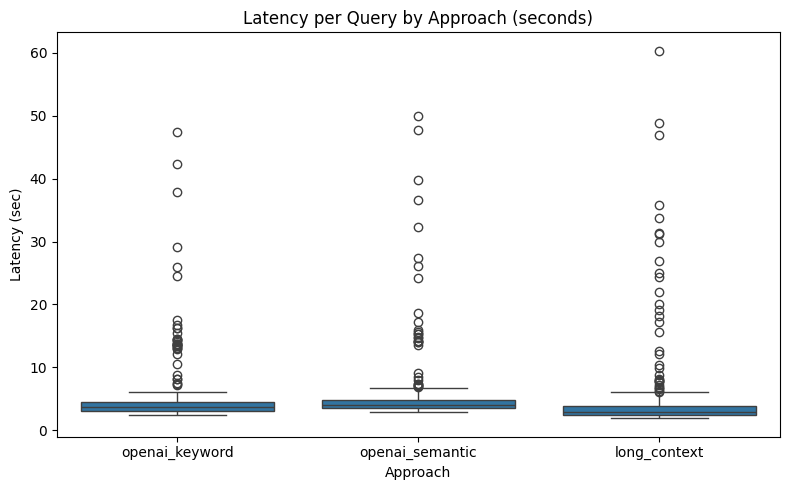

                 count  mean   std   min   25%   50%   75%    max
approach                                                         
long_context     324.0  4.69  6.70  1.90  2.42  2.82  3.88  60.36
openai_keyword   324.0  5.09  5.06  2.46  3.12  3.63  4.54  47.48
openai_semantic  324.0  5.40  5.55  2.88  3.50  4.00  4.82  49.97


In [6]:
# Chart 4: Latency Distribution by Approach
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="approach", y="latency_sec", ax=ax)
ax.set_title("Latency per Query by Approach (seconds)")
ax.set_xlabel("Approach"); ax.set_ylabel("Latency (sec)")
plt.tight_layout()
plt.show()
print(df.groupby("approach")["latency_sec"].describe().round(2))

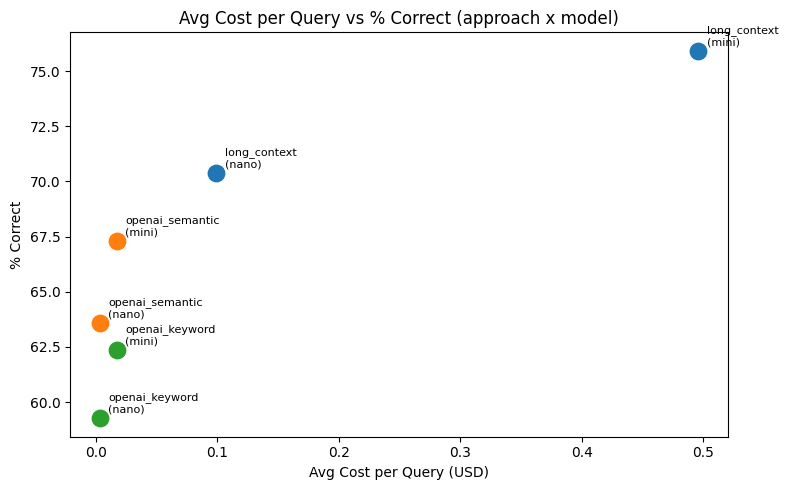

,approach,model,avg_cost,pct_correct
0,long_context,gpt-5.4-mini-2026-03-17,0.495788,75.925926
1,long_context,gpt-5.4-nano-2026-03-17,0.099176,70.370370
4,openai_semantic,gpt-5.4-mini-2026-03-17,0.017128,67.283951
5,openai_semantic,gpt-5.4-nano-2026-03-17,0.003425,63.580247
2,openai_keyword,gpt-5.4-mini-2026-03-17,0.017519,62.345679
3,openai_keyword,gpt-5.4-nano-2026-03-17,0.003490,59.259259


In [7]:
# Chart 5: Cost vs Correctness Scatter (aggregated — one point per approach x model)
agg_cost = (
    df.groupby(["approach", "model"])
    .agg(
        avg_cost=("price_usd", "mean"),
        pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"long_context": "tab:blue", "openai_semantic": "tab:orange", "openai_keyword": "tab:green"}
for _, row in agg_cost.iterrows():
    model_short = "mini" if "mini" in row["model"] else "nano"
    ax.scatter(row["avg_cost"], row["pct_correct"],
               s=140, color=colors.get(row["approach"], "gray"), zorder=3)
    ax.annotate(f"{row['approach']}\n({model_short})",
                (row["avg_cost"], row["pct_correct"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_title("Avg Cost per Query vs % Correct (approach x model)")
ax.set_xlabel("Avg Cost per Query (USD)")
ax.set_ylabel("% Correct")
plt.tight_layout()
plt.show()
display(agg_cost.sort_values("pct_correct", ascending=False))

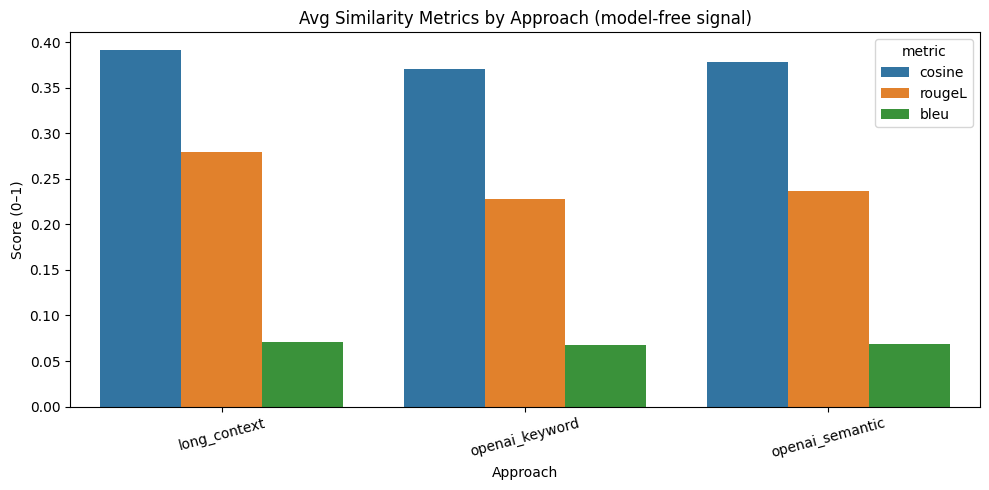

,cosine,rougeL,bleu
approach,,,
long_context,0.391,0.279,0.070
openai_keyword,0.370,0.228,0.067
openai_semantic,0.378,0.237,0.069


In [8]:
# Chart 6: Similarity Metrics (cosine / rougeL / bleu) by Approach
agg_sim = (
    df.groupby("approach")[["cosine", "rougeL", "bleu"]]
    .mean()
    .reset_index()
    .melt(id_vars="approach", var_name="metric", value_name="score")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=agg_sim, x="approach", y="score", hue="metric", ax=ax)
ax.set_title("Avg Similarity Metrics by Approach (model-free signal)")
ax.set_xlabel("Approach"); ax.set_ylabel("Score (0–1)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()
display(df.groupby("approach")[["cosine", "rougeL", "bleu"]].mean().round(3))

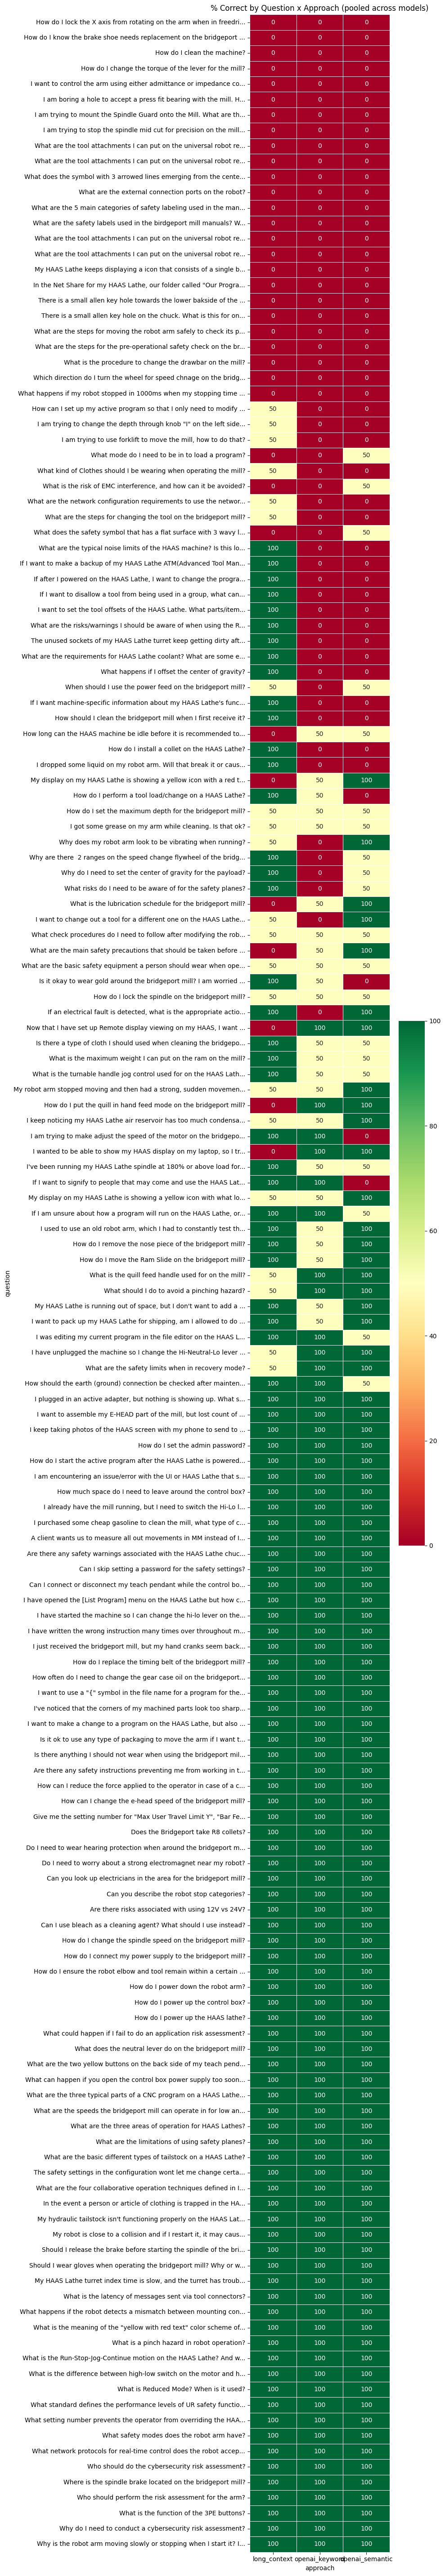

In [9]:
# Chart 7: Heatmap — Question x Approach correctness (pooled across models)
piv = (
    df.groupby(["question", "approach"])["judge_answer_correctness_vs_ref"]
    .mean()
    .unstack("approach") * 100
)
piv.index = piv.index.map(lambda q: q[:65] + "..." if len(q) > 65 else q)
piv = piv.loc[piv.mean(axis=1).sort_values().index]  # hardest at top

fig, ax = plt.subplots(figsize=(10, max(18, len(piv) * 0.35)))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, linewidths=0.5, ax=ax)
ax.set_title("% Correct by Question x Approach (pooled across models)")
plt.tight_layout()
plt.show()

In [10]:
# Chart 8: Universally Missed Questions (0% correct across all approaches + models)
q_overall = df.groupby("question")["judge_answer_correctness_vs_ref"].mean() * 100
zero_qs = q_overall[q_overall == 0].index.tolist()
print(f"{len(zero_qs)} questions scored 0% across ALL approaches and models:\n")

for i, q in enumerate(zero_qs, 1):
    print("=" * 80)
    print(f"Q{i}: {q}\n")
    gold = df.loc[df["question"] == q, "gold_answer"].iloc[0]
    print(f"GOLD ANSWER:\n{gold}\n")
    sample = df.loc[df["question"] == q].iloc[0]
    print(f"SAMPLE ({sample['approach']}, {sample['model']}):")
    print(f"{str(sample['generated_answer'])[:500]}\n")

23 questions scored 0% across ALL approaches and models:

Q1: How do I change the torque of the lever for the mill?

GOLD ANSWER:
You can change this using hi-lo mechanical lever. 

The Hi-Neutral-Lo Lever “O”, Figure 2.13, is used to put the attachment into either back gear or
direct drive. Rotate the spindle by hand to facilitate meshing of clutch or gears.

SAMPLE (openai_keyword, gpt-5.4-mini-2026-03-17):
The provided documents do not explain how to change the torque of the lever for the mill. They only list parts for the power feed assemblies, including standard torque and high torque motor options. [009__L1__Chapter_4_-_Parts_Listings__pp63-114__L2__14__6F_Power_Feed_X-Axis__pp97-99.pdf] [009__L1__Chapter_4_-_Parts_Listings__pp63-114__L2__15__8F_Power_Feed_X-Axis__pp100-103.pdf]

Q2: How do I clean the machine?

GOLD ANSWER:
Prepare the surface by removing loose dirt or debris. Apply a cleaning agent to the surface that needs cleaning, agitater the agent for stubborn spots, let t

In [ ]:
cobot_df = df[df["machine"] == "UR5e Cobot"]

,permutation_id,time_started,time_ended,total_elapsed_time,min_words_for_subsplit,approach,model,max_tokens,reasoning_effort,top_k,...,rougeL,bleu,q,judge_answer_correctness_vs_ref,judge_answer_helpfulness,text_correctness_vs_ref,text_helpfulness,latency_sec,price_usd,machine
102,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:35:54 EDT,2026-04-17 10:36:09 EDT,14.38 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.378378,0.251453,No. Connecting or disconnecting the teach pend...,True,True,Correctness: True\n\nStep-by-step reasoning:\n...,Relevance: True\n\nStep-by-step reasoning:\n1....,14.38,0.014396,UR5e Cobot
103,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:35:54 EDT,2026-04-17 10:35:57 EDT,2.75 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.205128,0.039699,No. Failure to set a password can result in in...,True,True,The ground truth explicitly says the answer is...,- The question is a direct yes/no about whethe...,2.75,0.015390,UR5e Cobot
104,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:35:54 EDT,2026-04-17 10:36:07 EDT,13.07 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.476190,0.131938,You should not use bleach as a cleaning soluti...,True,True,Correctness: True\n\nStep-by-step reasoning:\n...,Step-by-step reasoning:\n- The question has tw...,13.07,0.021980,UR5e Cobot
105,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:36:09 EDT,2026-04-17 10:36:13 EDT,4.13 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.566038,0.198573,There are three kinds of stop categories.\r\nS...,True,True,Correctness: True\n\nStep-by-step reasoning:\n...,Relevance: True\n\nStep-by-step reasoning:\n- ...,4.13,0.019554,UR5e Cobot
106,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:36:09 EDT,2026-04-17 10:36:25 EDT,16.29 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.166667,0.008802,Using one or the other is fine so long as the ...,True,True,Correctness: True\n\nStep-by-step reasoning:\n...,Relevance: True\n\nReasoning:\n- The question ...,16.29,0.018144,UR5e Cobot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
967,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 11:04:23 EDT,2026-04-17 11:04:26 EDT,2.87 Seconds,3000,long_context,gpt-5.4-nano-2026-03-17,5000,low,3,...,0.162162,0.016634,Remove obstacles in the area around the robot....,False,True,Correctness: False\n\nStep-by-step reasoning:\...,Step-by-step reasoning:\n- The question asks f...,2.87,0.099128,UR5e Cobot
968,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 11:04:23 EDT,2026-04-17 11:04:26 EDT,3.05 Seconds,3000,long_context,gpt-5.4-nano-2026-03-17,5000,low,3,...,0.380952,0.015263,"EN ISO 13849-1, Performance Level d (PLd), Cat...",True,True,Correctness: True\n\nStep-by-step reasoning:\n...,Relevance: True\n\nStep-by-step reasoning:\n- ...,3.05,0.099120,UR5e Cobot
969,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 11:04:23 EDT,2026-04-17 11:04:25 EDT,1.97 Seconds,3000,long_context,gpt-5.4-nano-2026-03-17,5000,low,3,...,0.444444,0.028144,Either the integrator(could be user) or a comp...,True,True,Step-by-step reasoning:\n- The ground truth sp...,Step-by-step reasoning:\n- The question asks s...,1.97,0.099109,UR5e Cobot
970,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 11:04:27 EDT,2026-04-17 11:04:30 EDT,2.33 Seconds,3000,long_context,gpt-5.4-nano-2026-03-17,5000,low,3,...,0.329412,0.075526,Risk assessment is the responsibility of the i...,True,True,Correctness: True\n\nStep-by-step reasoning:\n...,Relevance: True\n\nStep-by-step reasoning:\n- ...,2.33,0.099139,UR5e Cobot


In [14]:
# ============================================================
# UR5e Cobot Analysis
# ============================================================

cobot_df = df[df["machine"] == "UR5e Cobot"].copy()

print(f"Rows for UR5e Cobot: {len(cobot_df)}")
print(f"Questions: {cobot_df['question'].nunique()}")
print(f"Approaches: {sorted(cobot_df['approach'].unique())}")
print(f"Models: {sorted(cobot_df['model'].unique())}")

# ------------------------------------------------------------
# 1. Overall performance by approach x model
# ------------------------------------------------------------

cobot_perf = (
    cobot_df
    .groupby(["approach", "model"])
    .agg(
        n=("question", "count"),
        pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100),
        pct_helpful=("judge_answer_helpfulness", lambda x: x.mean() * 100),
        avg_tokens=("meta_total_tokens", "mean"),
        avg_latency=("latency_sec", "mean"),
        avg_cost=("price_usd", "mean"),
        avg_cosine=("cosine", "mean"),
        avg_rougeL=("rougeL", "mean"),
        avg_bleu=("bleu", "mean"),
    )
    .reset_index()
    .sort_values("pct_correct", ascending=False)
)

display(cobot_perf.round(3))

Rows for UR5e Cobot: 360
Questions: 60
Approaches: ['long_context', 'openai_keyword', 'openai_semantic']
Models: ['gpt-5.4-mini-2026-03-17', 'gpt-5.4-nano-2026-03-17']


,approach,model,n,pct_correct,pct_helpful,avg_tokens,avg_latency,avg_cost,avg_cosine,avg_rougeL,avg_bleu
0,long_context,gpt-5.4-mini-2026-03-17,60,78.333,83.333,247872.767,3.650,0.496,0.415,0.327,0.102
4,openai_semantic,gpt-5.4-mini-2026-03-17,60,75.000,85.000,8486.083,5.113,0.017,0.397,0.270,0.097
5,openai_semantic,gpt-5.4-nano-2026-03-17,60,70.000,78.333,8627.617,6.264,0.003,0.397,0.263,0.069
1,long_context,gpt-5.4-nano-2026-03-17,60,68.333,76.667,247931.350,5.220,0.099,0.387,0.284,0.053
3,openai_keyword,gpt-5.4-nano-2026-03-17,60,66.667,83.333,8701.467,3.984,0.003,0.383,0.253,0.071
2,openai_keyword,gpt-5.4-mini-2026-03-17,60,65.000,85.000,8715.767,6.479,0.017,0.398,0.266,0.097


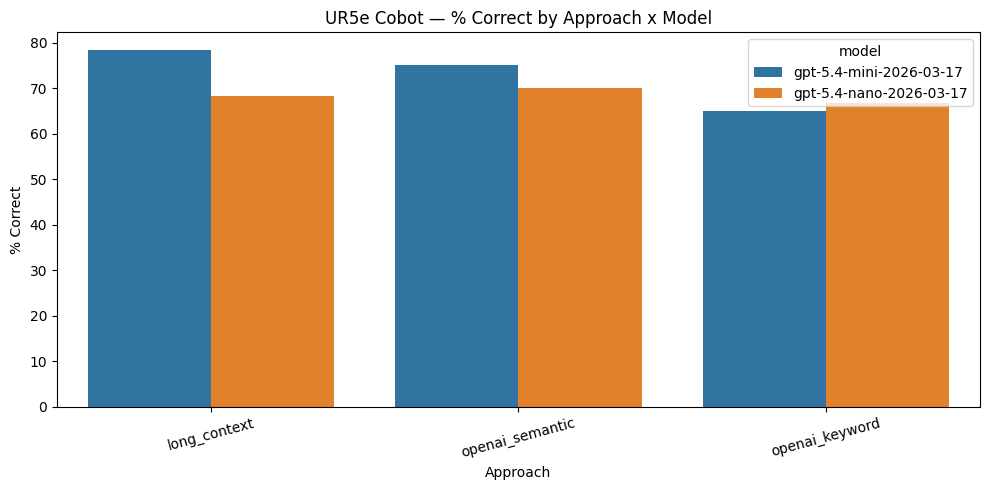

In [15]:
# ------------------------------------------------------------
# 2. Correctness chart: approach x model
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=cobot_perf,
    x="approach",
    y="pct_correct",
    hue="model",
    ax=ax
)

ax.set_title("UR5e Cobot — % Correct by Approach x Model")
ax.set_xlabel("Approach")
ax.set_ylabel("% Correct")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

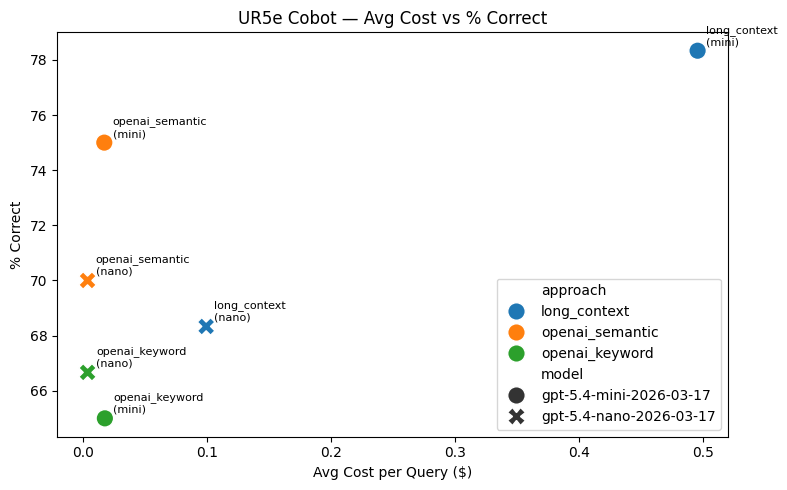

In [16]:
# ------------------------------------------------------------
# 4. Cost vs correctness
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=cobot_perf,
    x="avg_cost",
    y="pct_correct",
    hue="approach",
    style="model",
    s=160,
    ax=ax
)

for _, row in cobot_perf.iterrows():
    model_short = "mini" if "mini" in row["model"].lower() else "nano"
    ax.annotate(
        f"{row['approach']}\n({model_short})",
        (row["avg_cost"], row["pct_correct"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8
    )

ax.set_title("UR5e Cobot — Avg Cost vs % Correct")
ax.set_xlabel("Avg Cost per Query ($)")
ax.set_ylabel("% Correct")

plt.tight_layout()
plt.show()

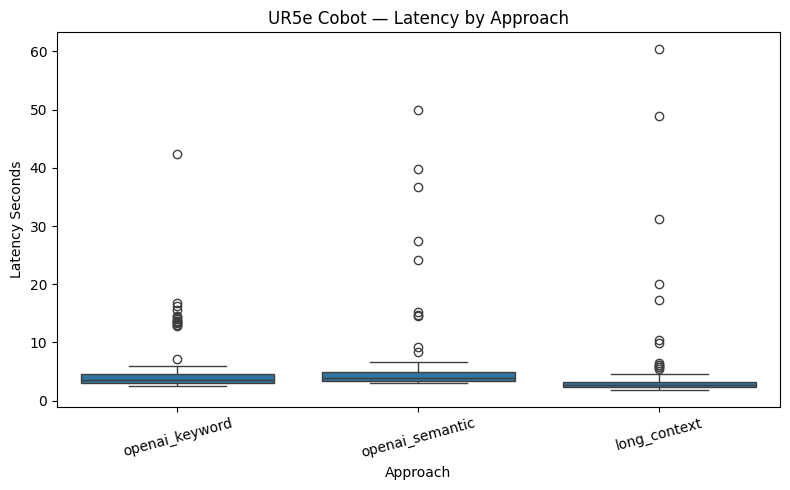

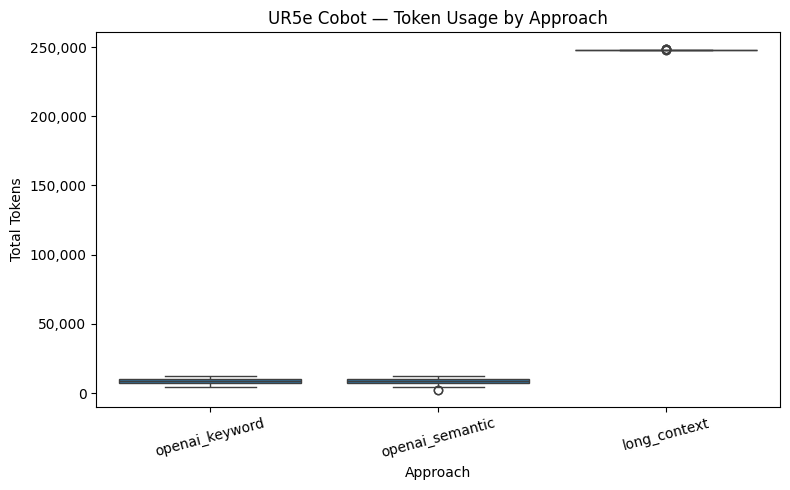

In [17]:
# ------------------------------------------------------------
# 5. Latency and token distribution
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=cobot_df,
    x="approach",
    y="latency_sec",
    ax=ax
)

ax.set_title("UR5e Cobot — Latency by Approach")
ax.set_xlabel("Approach")
ax.set_ylabel("Latency Seconds")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=cobot_df,
    x="approach",
    y="meta_total_tokens",
    ax=ax
)

ax.set_title("UR5e Cobot — Token Usage by Approach")
ax.set_xlabel("Approach")
ax.set_ylabel("Total Tokens")
ax.tick_params(axis="x", rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

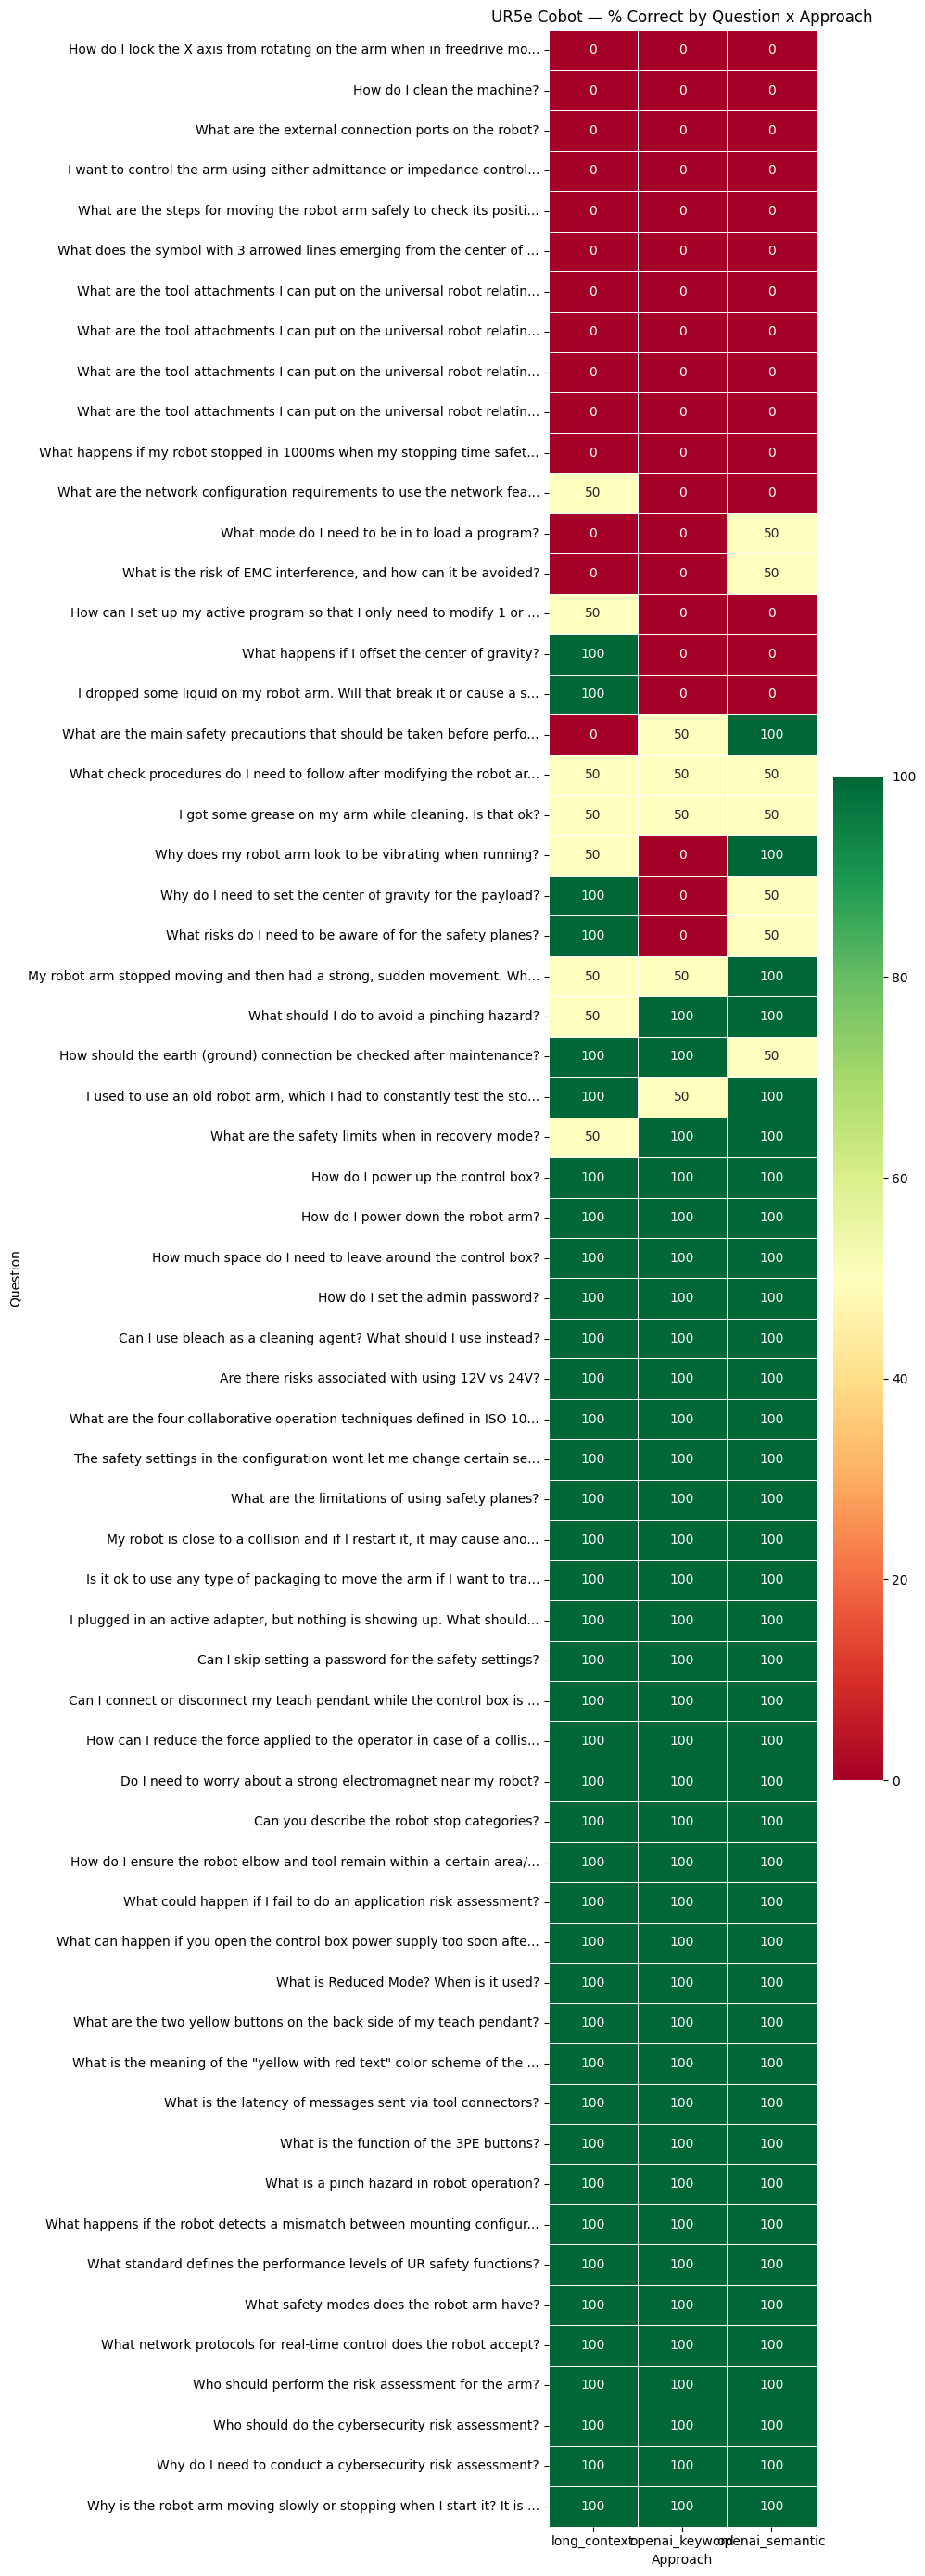

In [18]:
# ------------------------------------------------------------
# 6. Question-level correctness heatmap
# ------------------------------------------------------------

cobot_q_piv = (
    cobot_df
    .groupby(["question", "approach"])["judge_answer_correctness_vs_ref"]
    .mean()
    .unstack("approach") * 100
)

cobot_q_piv.index = cobot_q_piv.index.map(
    lambda q: q[:70] + "..." if len(q) > 70 else q
)

cobot_q_piv = cobot_q_piv.loc[
    cobot_q_piv.mean(axis=1).sort_values().index
]

fig, ax = plt.subplots(figsize=(10, max(8, len(cobot_q_piv) * 0.45)))

sns.heatmap(
    cobot_q_piv,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax
)

ax.set_title("UR5e Cobot — % Correct by Question x Approach")
ax.set_xlabel("Approach")
ax.set_ylabel("Question")

plt.tight_layout()
plt.show()